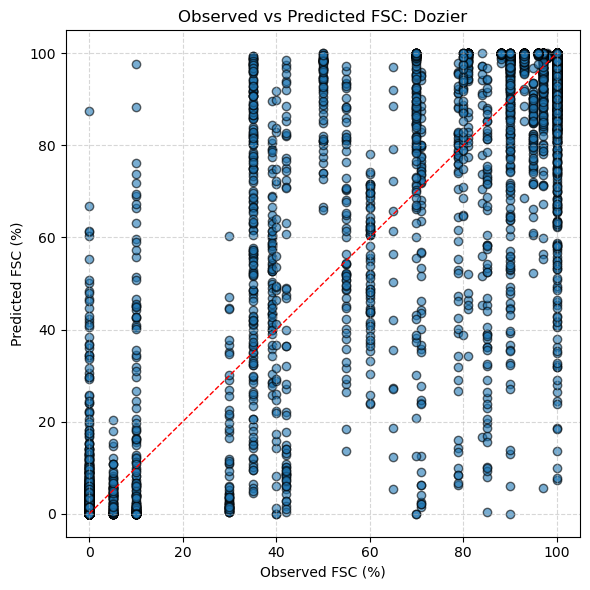

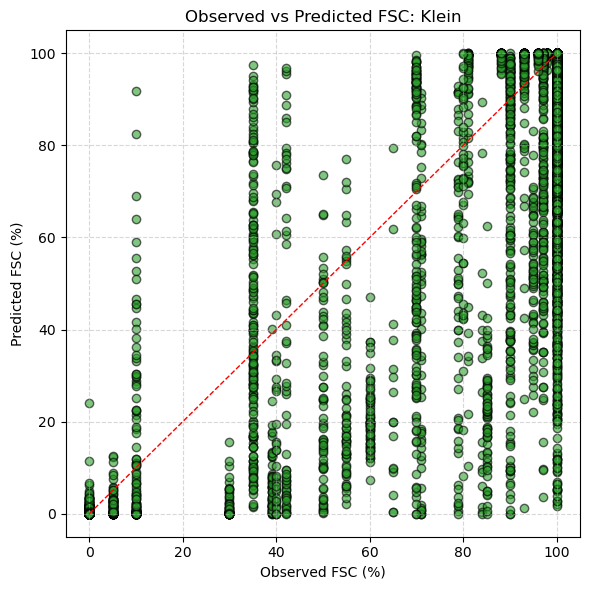

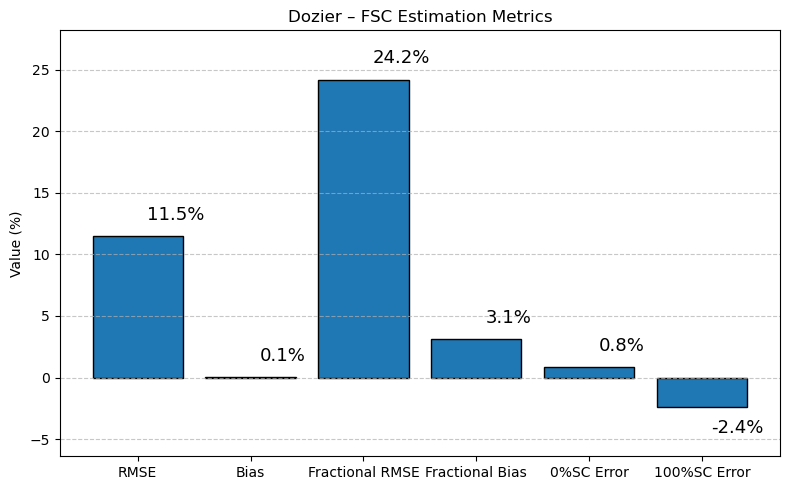

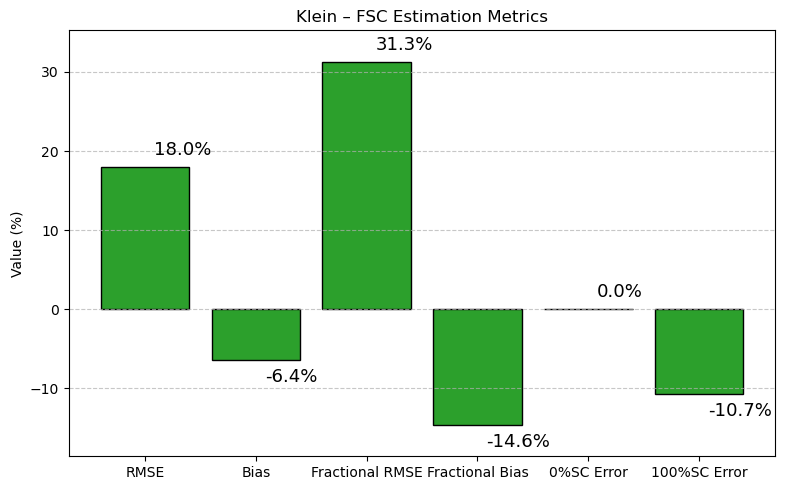

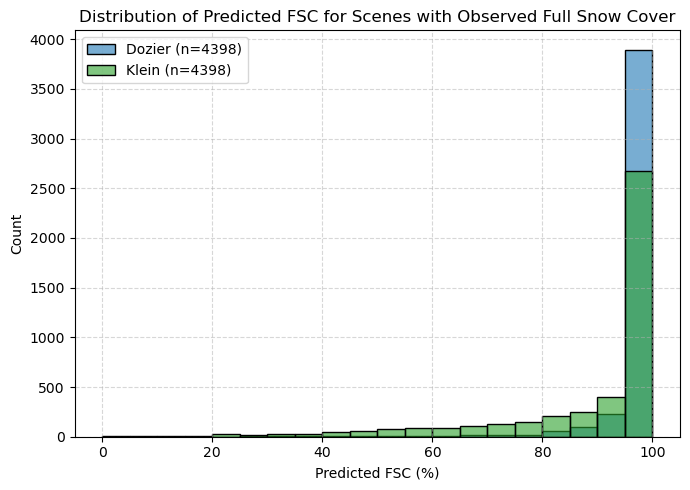

In [1]:
#80m

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

final_df = pd.read_pickle('landsat_aspect_results.pkl')

# final_df = pd.read_pickle('landsat_df_80m_0.2ff.pkl')
# final_df = final_df[final_df['cam']=='old_jack_pine']

# Melt the dataframe to long format for individual method plots
melted = final_df.melt(
    id_vars=["fsc", "filtered_fraction", "cam"],
    value_vars=["Dozier", "Klein"],  # , "Salomonson"
    var_name="method",
    value_name="predicted"
)

# Convert to percentages for plotting (0–100)
melted["fsc"] = melted["fsc"] * 100.0
melted["predicted"] = melted["predicted"] * 100.0

# Define color map (blue for Dozier, green for Klein)
method_colors = {
    "Dozier": "#1f77b4",
    "Klein": "#2ca02c",
    # "Salomonson": "#d62728"
}

# ---------- Scatter: Observed vs Predicted, one figure per method ----------
for method in ["Dozier", "Klein"]:  # , "Salomonson"
    subset = melted[melted["method"] == method]

    plt.figure(figsize=(6, 6))
    plt.scatter(
        subset["fsc"],
        subset["predicted"],
        alpha=0.6,
        edgecolor='k',
        c=method_colors[method],
        label=method
    )
    plt.plot([0, 100], [0, 100], 'r--', lw=1)
    plt.xlabel("Observed FSC (%)")
    plt.ylabel("Predicted FSC (%)")
    plt.title(f"Observed vs Predicted FSC: {method}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig(f'poster_landsat_{method}_actual_predicted.svg')
    plt.show()

# ---------- Metric helpers ----------
def rmse(y_true, y_pred):
    diff = y_pred - y_true
    return np.sqrt(np.nanmean(diff**2)) if np.isfinite(diff).any() else np.nan

def bias(y_true, y_pred):
    diff = y_pred - y_true
    return np.nanmean(diff) if np.isfinite(diff).any() else np.nan

def compute_all_metrics(df_method):
    """df_method: melted subset for a single method, with fsc/predicted in 0–100 units."""
    y = df_method["fsc"].to_numpy()
    yhat = df_method["predicted"].to_numpy()

    # Overall
    overall_rmse  = rmse(y, yhat)
    overall_bias  = bias(y, yhat)

    # Fractional (strictly between 0 and 100)
    frac_mask = (y > 0) & (y < 100)
    frac_rmse  = rmse(y[frac_mask], yhat[frac_mask])
    frac_bias  = bias(y[frac_mask], yhat[frac_mask])

    # Errors at the extremes
    zero_mask = (y == 0)
    full_mask = (y == 100)

    zero_bias = bias(y[zero_mask], yhat[zero_mask])   # "0%SC Error"
    full_bias = bias(y[full_mask], yhat[full_mask])   # "100%SC Error"

    metrics_order = ["RMSE", "Bias", "Fractional RMSE", "Fractional Bias", "0%SC Error", "100%SC Error"]
    values = np.array([
        overall_rmse,
        overall_bias,
        frac_rmse,
        frac_bias,
        zero_bias,
        full_bias
    ], dtype=float)

    return metrics_order, values

# ---------- Bar chart per method with six metrics ----------
for method in ["Dozier", "Klein"]:
    subset = melted[melted["method"] == method]
    metrics_labels, values = compute_all_metrics(subset)

    plt.figure(figsize=(8, 5))
    x = np.arange(len(metrics_labels))
    bars = plt.bar(x, values, edgecolor='black', color=method_colors[method])

    # Labels on bars (handle NaNs gracefully)
    for bar, val in zip(bars, values):
        height = 0 if np.isnan(val) else float(val)
        txt = "NaN" if np.isnan(val) else f"{height:.1f}%"
        x_offset = bar.get_x() + bar.get_width() * 0.6
        y_offset = 1 * np.sign(height if height != 0 else 1)
        plt.text(
            x_offset,
            height + y_offset,
            txt,
            ha='left',
            va='bottom' if height >= 0 else 'top',
            fontsize=13
        )

    plt.xticks(x, metrics_labels, rotation=0)
    plt.ylabel("Value (%)")
    plt.title(f"{method} – FSC Estimation Metrics")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Y-lims with padding, robust to NaNs
    finite_vals = values[np.isfinite(values)]
    if finite_vals.size == 0:
        ymin, ymax = -1, 1
    else:
        ymin = min(0.0, float(finite_vals.min())) - 4
        ymax = (float(finite_vals.max()) + 4) if float(finite_vals.max()) > 0 else 1
    plt.ylim(ymin, ymax)

    plt.tight_layout()
    # plt.savefig(f'poster_landsat_{method}_metrics.svg')
    plt.show()

# ---------- Histogram: Predicted FSC where observed FSC = 100% ----------

# Filter scenes where observed FSC is 100%
full_snow = melted[melted["fsc"] == 100].copy()

# Set up plot
plt.figure(figsize=(7, 5))
bins = np.linspace(0, 100, 21)  # 0–100 in 5% increments

for method in ["Dozier", "Klein"]:
# for method in ["Klein"]:
    subset = full_snow[full_snow["method"] == method]
    sns.histplot(
        subset["predicted"],
        bins=bins,
        kde=False,
        color=method_colors[method],
        label=f"{method} (n={len(subset)})",
        alpha=0.6,
        edgecolor="black"
    )

# Reference line at 100% (perfect prediction)
# plt.axvline(100, color="red", linestyle="--", linewidth=1, label="Observed = 100%")

plt.xlabel("Predicted FSC (%)")
plt.ylabel("Count")
plt.title("Distribution of Predicted FSC for Scenes with Observed Full Snow Cover")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("poster_landsat_full_snow_hist.svg")
plt.show()

In [17]:
final_df['cam'].unique()

array(['delta_junction', 'hyytiala', 'kenttarova', 'lacclair', 'marcell',
       'oregon', 'sodankyla', 'torgnon', 'underc', 'underhill',
       'willowcreek', 'bartlett', 'glees', 'old_jack_pine', 'queens',
       'tammela', 'varrio', 'wslcreek'], dtype=object)

Number of plotted cells: 12131


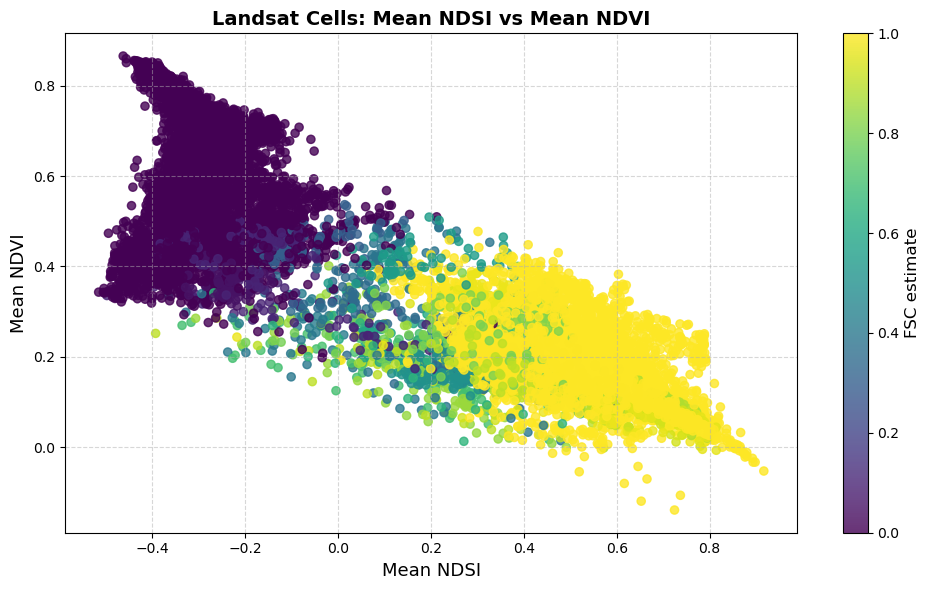

In [5]:
import matplotlib.pyplot as plt

plot_df = final_df.dropna(subset=['ndsi_mean', 'ndvi_mean', 'fsc']).copy()

print(f"Number of plotted cells: {len(plot_df)}")

plt.figure(figsize=(10, 6))

sc = plt.scatter(
    plot_df['ndsi_mean'],
    plot_df['ndvi_mean'],
    c=plot_df['fsc'],
    s=35,
    alpha=0.8
)

plt.xlabel('Mean NDSI', fontsize=13)
plt.ylabel('Mean NDVI', fontsize=13)
plt.title('Landsat Cells: Mean NDSI vs Mean NDVI', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

cbar = plt.colorbar(sc)
cbar.set_label('FSC estimate', fontsize=12)

plt.tight_layout()
plt.show()

Number of plotted cells: 12131
Selected partial-snow cells, 0 < fsc < 1: 808

Number of highlighted partial-snow cells per site:
cam
marcell        320
sodankyla      295
torgnon         96
willowcreek     64
glees           33
Name: count, dtype: int64


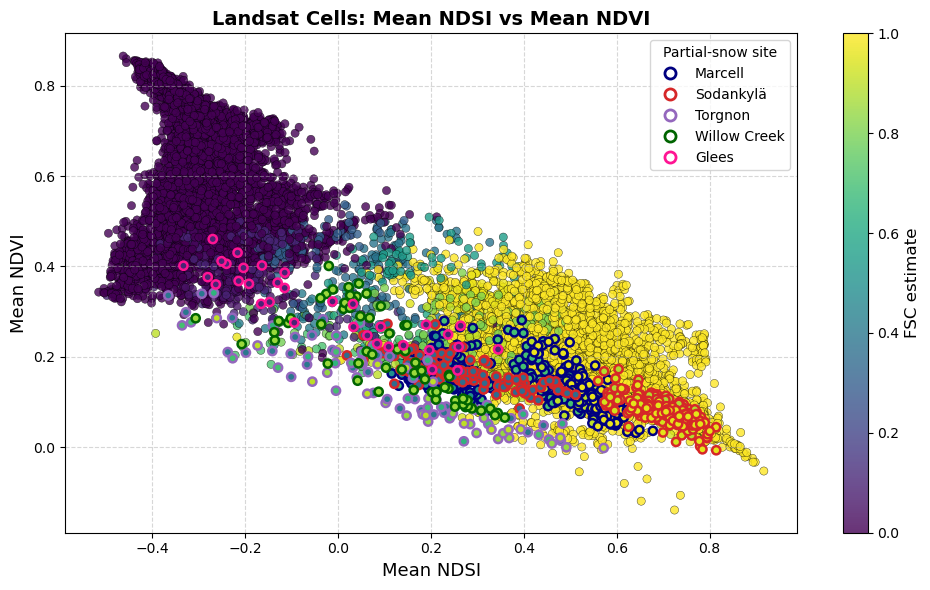

In [19]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
plot_df = final_df.dropna(
    subset=['ndsi_mean', 'ndvi_mean', 'fsc', 'cam']
).copy()

print(f"Number of plotted cells: {len(plot_df)}")


# ------------------------------------------------------------
# Selected partial-snow sites
# ------------------------------------------------------------
selected_sites = [
    'marcell',
    'sodankyla',
    'torgnon',
    'willowcreek',
    'glees'
]


# ------------------------------------------------------------
# Outline colours
# ------------------------------------------------------------
site_colours = {
    'marcell': '#000080',       # navy
    'sodankyla': '#d62728',     # red
    'torgnon': '#9467bd',       # purple
    'willowcreek': '#006400',   # dark green
    'glees': '#ff1493'          # hot pink
}


site_labels = {
    'marcell': 'Marcell',
    'sodankyla': 'Sodankylä',
    'torgnon': 'Torgnon',
    'willowcreek': 'Willow Creek',
    'glees': 'Glees'
}


# ------------------------------------------------------------
# Plot order from back to front
#
# Marcell      = furthest back
# Sodankyla
# Torgnon
# Willow Creek
# Glees        = plotted last, always on top
# ------------------------------------------------------------
highlight_order = [
    'marcell',
    'sodankyla',
    'torgnon',
    'willowcreek',
    'glees'
]


# ------------------------------------------------------------
# Isolate partial-snow cells from selected sites
# ------------------------------------------------------------
partial_selected = plot_df[
    (plot_df['fsc'] > 0) &
    (plot_df['fsc'] < 1) &
    (plot_df['cam'].isin(selected_sites))
].copy()


print(
    f"Selected partial-snow cells, 0 < fsc < 1: "
    f"{len(partial_selected)}"
)

print("\nNumber of highlighted partial-snow cells per site:")
print(
    partial_selected['cam']
    .value_counts()
    .reindex(selected_sites, fill_value=0)
)


# ------------------------------------------------------------
# Shared colour scale
# ------------------------------------------------------------
norm = Normalize(vmin=0, vmax=1)
cmap = 'viridis'


# ------------------------------------------------------------
# Plot all cells
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    plot_df['ndsi_mean'],
    plot_df['ndvi_mean'],
    c=plot_df['fsc'],
    cmap=cmap,
    norm=norm,
    s=35,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.3
)


# ------------------------------------------------------------
# Redraw selected partial-snow cells with coloured outlines
# ------------------------------------------------------------
for i, site in enumerate(highlight_order):

    site_data = partial_selected[
        partial_selected['cam'] == site
    ]

    ax.scatter(
        site_data['ndsi_mean'],
        site_data['ndvi_mean'],
        c=site_data['fsc'],
        cmap=cmap,
        norm=norm,
        s=35,
        alpha=1.0,
        edgecolors=site_colours[site],
        linewidths=1.8,
        zorder=10 + i
    )


# ------------------------------------------------------------
# Colourbar
# ------------------------------------------------------------
cbar = fig.colorbar(sc, ax=ax)

cbar.set_label(
    'FSC estimate',
    fontsize=12
)


# ------------------------------------------------------------
# Site legend
# ------------------------------------------------------------
site_legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor=site_colours[site],
        markeredgewidth=2,
        markersize=8,
        label=site_labels[site]
    )
    for site in selected_sites
]


ax.legend(
    handles=site_legend_handles,
    title='Partial-snow site',
    loc='upper right',
    frameon=True
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel(
    'Mean NDSI',
    fontsize=13
)

ax.set_ylabel(
    'Mean NDVI',
    fontsize=13
)

ax.set_title(
    'Landsat Cells: Mean NDSI vs Mean NDVI',
    fontsize=14,
    weight='bold'
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

Number of plotted cells: 12131
Selected 100% snow-cover cells, fsc == 1: 893

Number of highlighted 100% snow-cover cells per site:
cam
underc      375
wslcreek    168
bartlett    160
torgnon     128
queens       62
Name: count, dtype: int64


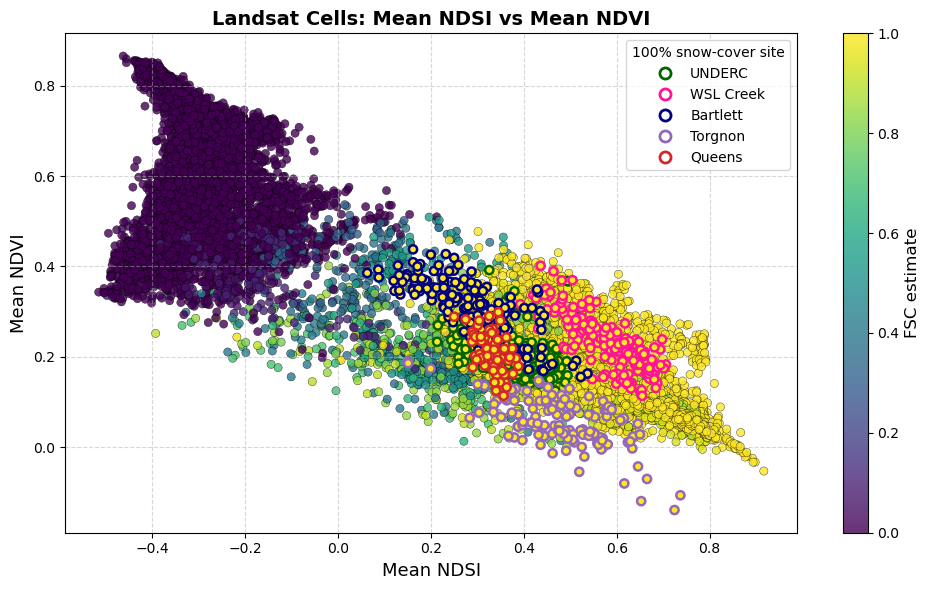

In [24]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
import numpy as np

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
plot_df = final_df.dropna(
    subset=['ndsi_mean', 'ndvi_mean', 'fsc', 'cam']
).copy()

print(f"Number of plotted cells: {len(plot_df)}")


# ------------------------------------------------------------
# Selected 100% snow-cover sites
# ------------------------------------------------------------
selected_sites = [
    'underc',
    'wslcreek',
    'bartlett',
    'torgnon',
    'queens'
]


# ------------------------------------------------------------
# Outline colours
# ------------------------------------------------------------
site_colours = {
    'bartlett': '#000080',   # navy
    'queens': '#d62728',     # red
    'torgnon': '#9467bd',    # purple
    'underc': '#006400',     # dark green
    'wslcreek': '#ff1493'    # hot pink
}


site_labels = {
    'bartlett': 'Bartlett',
    'queens': 'Queens',
    'torgnon': 'Torgnon',
    'underc': 'UNDERC',
    'wslcreek': 'WSL Creek'
}


# ------------------------------------------------------------
# Plot order from back to front
# ------------------------------------------------------------
highlight_order = [
    'underc',
    'wslcreek',
    'bartlett',
    'torgnon',
    'queens'
]


# ------------------------------------------------------------
# Isolate 100% snow-cover cells from selected sites
# ------------------------------------------------------------
full_snow_selected = plot_df[
    np.isclose(plot_df['fsc'], 1) &
    (plot_df['cam'].isin(selected_sites))
].copy()


print(
    f"Selected 100% snow-cover cells, fsc == 1: "
    f"{len(full_snow_selected)}"
)

print("\nNumber of highlighted 100% snow-cover cells per site:")
print(
    full_snow_selected['cam']
    .value_counts()
    .reindex(selected_sites, fill_value=0)
)


# ------------------------------------------------------------
# Shared colour scale
# ------------------------------------------------------------
norm = Normalize(vmin=0, vmax=1)
cmap = 'viridis'


# ------------------------------------------------------------
# Plot all cells
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    plot_df['ndsi_mean'],
    plot_df['ndvi_mean'],
    c=plot_df['fsc'],
    cmap=cmap,
    norm=norm,
    s=35,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.3
)


# ------------------------------------------------------------
# Redraw selected 100% snow-cover cells with coloured outlines
# ------------------------------------------------------------
for i, site in enumerate(highlight_order):

    site_data = full_snow_selected[
        full_snow_selected['cam'] == site
    ]

    ax.scatter(
        site_data['ndsi_mean'],
        site_data['ndvi_mean'],
        c=site_data['fsc'],
        cmap=cmap,
        norm=norm,
        s=35,
        alpha=1.0,
        edgecolors=site_colours[site],
        linewidths=1.8,
        zorder=10 + i
    )


# ------------------------------------------------------------
# Colourbar
# ------------------------------------------------------------
cbar = fig.colorbar(sc, ax=ax)

cbar.set_label(
    'FSC estimate',
    fontsize=12
)


# ------------------------------------------------------------
# Site legend
# ------------------------------------------------------------
site_legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor=site_colours[site],
        markeredgewidth=2,
        markersize=8,
        label=site_labels[site]
    )
    for site in selected_sites
]


ax.legend(
    handles=site_legend_handles,
    title='100% snow-cover site',
    loc='upper right',
    frameon=True
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel(
    'Mean NDSI',
    fontsize=13
)

ax.set_ylabel(
    'Mean NDVI',
    fontsize=13
)

ax.set_title(
    'Landsat Cells: Mean NDSI vs Mean NDVI',
    fontsize=14,
    weight='bold'
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

Number of plotted cells: 12131
Selected 100% snow-cover cells, fsc == 1: 893

Number of highlighted 100% snow-cover cells per site:
cam
bartlett    160
queens       62
torgnon     128
underc      375
wslcreek    168
Name: count, dtype: int64


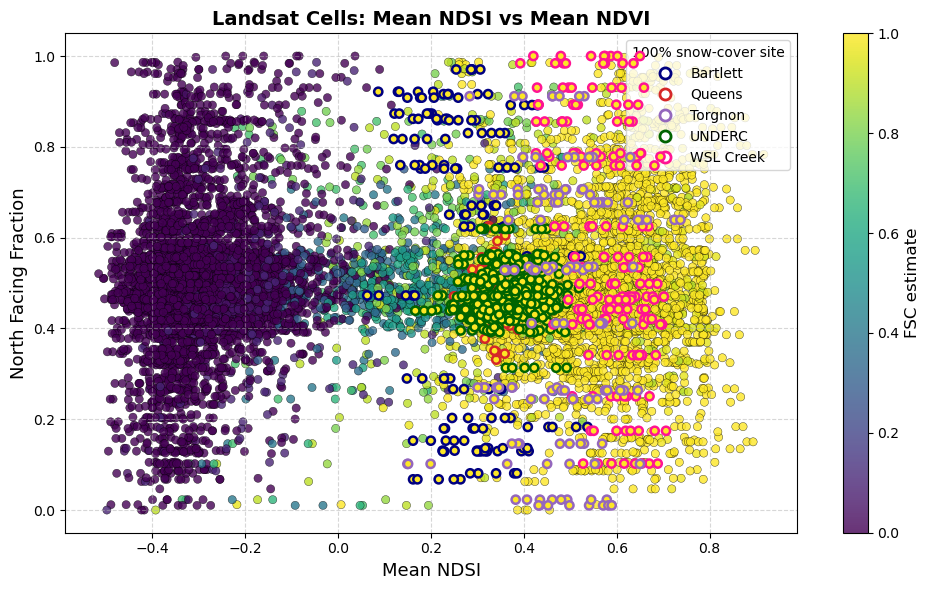

In [23]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
import numpy as np

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
plot_df = final_df.dropna(
    subset=['ndsi_mean', 'north_facing_fraction', 'fsc', 'cam']
).copy()

print(f"Number of plotted cells: {len(plot_df)}")


# ------------------------------------------------------------
# Selected 100% snow-cover sites
# ------------------------------------------------------------
selected_sites = [
    'bartlett',
    'queens',
    'torgnon',
    'underc',
    'wslcreek'
]


# ------------------------------------------------------------
# Outline colours
# ------------------------------------------------------------
site_colours = {
    'bartlett': '#000080',   # navy
    'queens': '#d62728',     # red
    'torgnon': '#9467bd',    # purple
    'underc': '#006400',     # dark green
    'wslcreek': '#ff1493'    # hot pink
}


site_labels = {
    'bartlett': 'Bartlett',
    'queens': 'Queens',
    'torgnon': 'Torgnon',
    'underc': 'UNDERC',
    'wslcreek': 'WSL Creek'
}


# ------------------------------------------------------------
# Plot order from back to front
# ------------------------------------------------------------
highlight_order = [
    'bartlett',
    'queens',
    'underc',
    'wslcreek',
    'torgnon'
]


# ------------------------------------------------------------
# Isolate 100% snow-cover cells from selected sites
# ------------------------------------------------------------
full_snow_selected = plot_df[
    np.isclose(plot_df['fsc'], 1) &
    (plot_df['cam'].isin(selected_sites))
].copy()


print(
    f"Selected 100% snow-cover cells, fsc == 1: "
    f"{len(full_snow_selected)}"
)

print("\nNumber of highlighted 100% snow-cover cells per site:")
print(
    full_snow_selected['cam']
    .value_counts()
    .reindex(selected_sites, fill_value=0)
)


# ------------------------------------------------------------
# Shared colour scale
# ------------------------------------------------------------
norm = Normalize(vmin=0, vmax=1)
cmap = 'viridis'


# ------------------------------------------------------------
# Plot all cells
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    plot_df['ndsi_mean'],
    plot_df['north_facing_fraction'],
    c=plot_df['fsc'],
    cmap=cmap,
    norm=norm,
    s=35,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.3
)


# ------------------------------------------------------------
# Redraw selected 100% snow-cover cells with coloured outlines
# ------------------------------------------------------------
for i, site in enumerate(highlight_order):

    site_data = full_snow_selected[
        full_snow_selected['cam'] == site
    ]

    ax.scatter(
        site_data['ndsi_mean'],
        site_data['north_facing_fraction'],
        c=site_data['fsc'],
        cmap=cmap,
        norm=norm,
        s=35,
        alpha=1.0,
        edgecolors=site_colours[site],
        linewidths=1.8,
        zorder=10 + i
    )


# ------------------------------------------------------------
# Colourbar
# ------------------------------------------------------------
cbar = fig.colorbar(sc, ax=ax)

cbar.set_label(
    'FSC estimate',
    fontsize=12
)


# ------------------------------------------------------------
# Site legend
# ------------------------------------------------------------
site_legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor=site_colours[site],
        markeredgewidth=2,
        markersize=8,
        label=site_labels[site]
    )
    for site in selected_sites
]


ax.legend(
    handles=site_legend_handles,
    title='100% snow-cover site',
    loc='upper right',
    frameon=True
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel(
    'Mean NDSI',
    fontsize=13
)

ax.set_ylabel(
    'North Facing Fraction',
    fontsize=13
)

ax.set_title(
    'Landsat Cells: Mean NDSI vs Mean NDVI',
    fontsize=14,
    weight='bold'
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

North-facing cells: 5266
South-facing cells: 6846


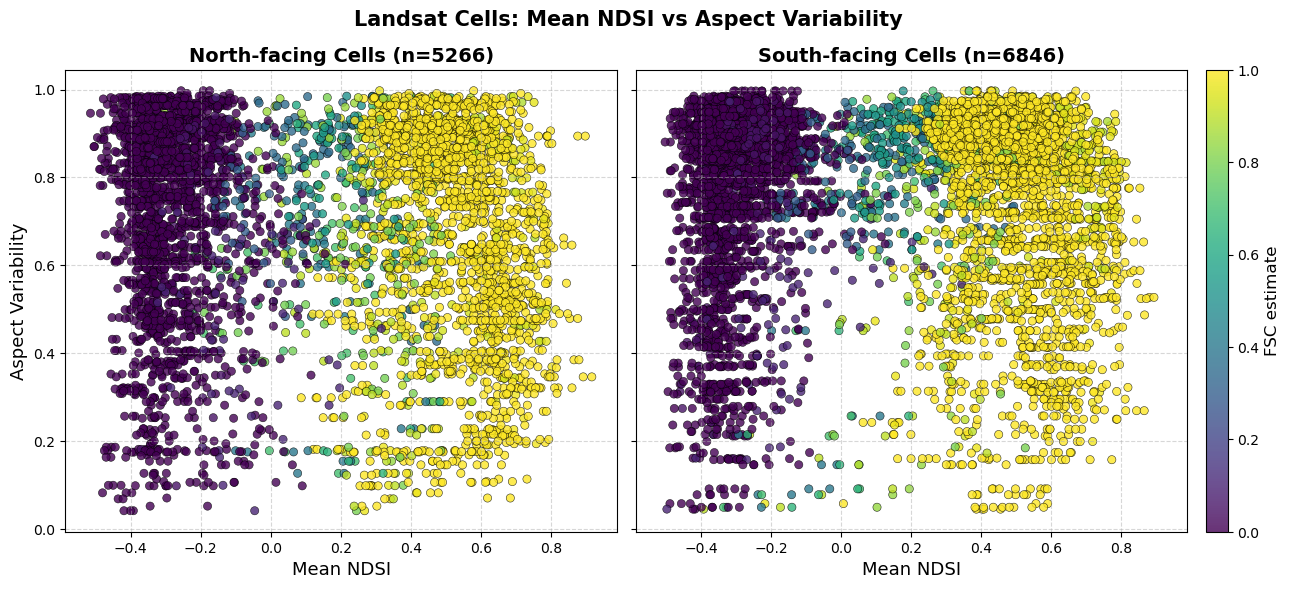

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
dominance_threshold = 0.5

# ------------------------------------------------------------
# Keep complete rows
# ------------------------------------------------------------
plot_df = final_df.dropna(
    subset=[
        'ndsi_mean',
        'aspect_variability',
        'north_facing_fraction',
        'fsc'
    ]
).copy()

# ------------------------------------------------------------
# Separate north- and south-facing cells
# ------------------------------------------------------------
north_df = plot_df[
    plot_df['north_facing_fraction'] > dominance_threshold
].copy()

south_df = plot_df[
    plot_df['north_facing_fraction'] < (1 - dominance_threshold)
].copy()

print(f"North-facing cells: {len(north_df)}")
print(f"South-facing cells: {len(south_df)}")

# ------------------------------------------------------------
# Shared axis ranges
# ------------------------------------------------------------
x_min = plot_df['ndsi_mean'].min()
x_max = plot_df['ndsi_mean'].max()

y_min = plot_df['aspect_variability'].min()
y_max = plot_df['aspect_variability'].max()

# Small padding
x_pad = 0.05 * (x_max - x_min)
y_pad = 0.05 * (y_max - y_min)

xlim = (x_min - x_pad, x_max + x_pad)
ylim = (y_min - y_pad, y_max + y_pad)

# ------------------------------------------------------------
# Shared colour scale
# ------------------------------------------------------------
norm = Normalize(vmin=0, vmax=1)
cmap = 'viridis'

# ------------------------------------------------------------
# Figure layout:
# two equally sized plots + dedicated colourbar axis
# ------------------------------------------------------------
fig = plt.figure(figsize=(15, 6))

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1, 1, 0.04],
    wspace=0.05
)

ax_north = fig.add_subplot(gs[0, 0])
ax_south = fig.add_subplot(gs[0, 1], sharex=ax_north, sharey=ax_north)
cax = fig.add_subplot(gs[0, 2])

# ------------------------------------------------------------
# North-facing cells
# ------------------------------------------------------------
sc_north = ax_north.scatter(
    north_df['ndsi_mean'],
    north_df['aspect_variability'],
    c=north_df['fsc'],
    cmap=cmap,
    norm=norm,
    s=35,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.4
)

ax_north.set_title(
    f'North-facing Cells (n={len(north_df)})',
    fontsize=14,
    weight='bold'
)

ax_north.set_xlabel('Mean NDSI', fontsize=13)
ax_north.set_ylabel('Aspect Variability', fontsize=13)

ax_north.set_xlim(xlim)
ax_north.set_ylim(ylim)

ax_north.grid(
    True,
    linestyle='--',
    alpha=0.5
)

# ------------------------------------------------------------
# South-facing cells
# ------------------------------------------------------------
sc_south = ax_south.scatter(
    south_df['ndsi_mean'],
    south_df['aspect_variability'],
    c=south_df['fsc'],
    cmap=cmap,
    norm=norm,
    s=35,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.4
)

ax_south.set_title(
    f'South-facing Cells (n={len(south_df)})',
    fontsize=14,
    weight='bold'
)

ax_south.set_xlabel('Mean NDSI', fontsize=13)

ax_south.set_xlim(xlim)
ax_south.set_ylim(ylim)

ax_south.grid(
    True,
    linestyle='--',
    alpha=0.5
)

# Hide repeated y-axis tick labels on right plot
ax_south.tick_params(
    axis='y',
    labelleft=False
)

# ------------------------------------------------------------
# Shared FSC colourbar in its own axis
# ------------------------------------------------------------
cbar = fig.colorbar(
    sc_north,
    cax=cax
)

cbar.set_label(
    'FSC estimate',
    fontsize=12
)

# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------
fig.suptitle(
    'Landsat Cells: Mean NDSI vs Aspect Variability',
    fontsize=15,
    weight='bold',
    y=0.98
)

# Leave room for main title
fig.subplots_adjust(
    top=0.88
)

plt.show()

In [15]:
final_df.columns

Index(['sampling_mode', 'grid_row', 'grid_col', 'grid_cell_id', 'sim_id',
       'beam_pair', 'anchor_beam_pair', 'anchor_edge', 'orientation',
       'offset_m', 'lat_bin', 'lat_bin_y_min', 'lat_bin_y_max', 'track_x0',
       'track_y0', 'track_x1', 'track_y1', 'box_center_lon', 'box_center_lat',
       'box_center_x', 'box_center_y', 'box_left', 'box_right', 'box_bottom',
       'box_top', 'pixel_count', 'valid_pixel_count', 'filtered_fraction',
       'north_facing_fraction', 'aspect_variability', 'gradient_p16',
       'gradient_p50', 'gradient_p84', 'topography_valid_pixel_count',
       'ndsi_mean', 'ndsi_p16', 'ndsi_p50', 'ndsi_p84', 'ndvi_mean',
       'ndvi_p16', 'ndvi_p50', 'ndvi_p84', 'green_mean', 'green_p16',
       'green_p50', 'green_p84', 'red_mean', 'red_p16', 'red_p50', 'red_p84',
       'nir_mean', 'nir_p16', 'nir_p50', 'nir_p84', 'swir_mean', 'swir_p16',
       'swir_p50', 'swir_p84', 'Dozier', 'Klein', 'Salomonson', 'fsc', 'cam',
       'filepath', 'landsat_scene_i